<a href="https://colab.research.google.com/github/cyberlynxes/homework/blob/main/hppp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================================
# CELL 1: 安装所有需要的库
# ============================================================
!pip install semopy causal-learn shap xgboost scikit-learn statsmodels \
    matplotlib seaborn pandas numpy scipy networkx graphviz \
    prince pingouin -q

print("✅ 所有库安装完成")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.3/204.3 kB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.8/194.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 204.0/204.0 kB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.3/94.3 kB 6.3 MB/s eta 0:00:00
✅ 所有库安装完成


In [ ]:
# ============================================================
# CELL 2: 导入所有库
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 统计与回归
from sklearn.linear_model import ElasticNetCV, LassoCV, RidgeCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm
from scipy import stats

# 树模型 + SHAP
import xgboost as xgb
import shap

# PLS-SEM
import semopy

# Causal Discovery
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ScoreBased.GES import ges
from causallearn.utils.GraphUtils import GraphUtils

print("✅ 所有库导入成功")


✅ 所有库导入成功


In [ ]:
# ============================================================
# CELL 3: 上传数据文件
# ============================================================
from google.colab import files

print("请上传 etfs_details_affordable_real_estate.csv 文件:")
uploaded = files.upload()

# 获取文件名
filename = list(uploaded.keys())[0]
print(f"\n✅ 文件 '{filename}' 上传成功")


请上传 etfs_details_affordable_real_estate.csv 文件:


Saving etfs_details_affordable_real_estate.csv to etfs_details_affordable_real_estate.csv

✅ 文件 'etfs_details_affordable_real_estate.csv' 上传成功


In [ ]:
# ============================================================
# CELL 4: 读取原始数据并查看基本信息
# ============================================================
df_raw = pd.read_csv(filename)

print("=" * 60)
print("原始数据基本信息")
print("=" * 60)
print(f"行数: {df_raw.shape[0]}")
print(f"列数: {df_raw.shape[1]}")
print(f"\n列名列表:")
for i, col in enumerate(df_raw.columns):
    print(f"  {i+1:3d}. {col}")

print(f"\n前3行预览:")
df_raw.head(3)


原始数据基本信息
行数: 3315
列数: 46

列名列表:
    1. Symbol
    2. ETF Name
    3. Total Assets
    4. YTD
    5. Avg Volume
    6. Previous Closing Price
    7. 1-Day Change
    8. 1 Week
    9. 1 Month
   10. 1 Year
   11. 3 Year
   12. 5 Year
   13. YTD FF
   14. 1 Week FF
   15. 4 Week FF
   16. 1 Year FF
   17. 3 Year FF
   18. 5 Year FF
   19. ETF Database Category
   20. Inception
   21. ER
   22. Commission Free
   23. Annual Dividend Rate
   24. Dividend Date
   25. Dividend
   26. Annual Dividend Yield %
   27. P/E Ratio
   28. Beta
   29. # of Holdings
   30. % In Top 10
   31. ST Cap Gain Rate
   32. LT Cap Gain Rate
   33. Tax Form
   34. Lower Bollinger
   35. Upper Bollinger
   36. Support 1
   37. Resistance 1
   38. RSI
   39. Overall Rating
   40. Liquidity Rating
   41. Expenses Rating
   42. Returns Rating
   43. Volatility Rating
   44. Dividend Rating
   45. Concentration Rating
   46. Revenue Exposure to Affordable Real Estate (%)

前3行预览:


,Symbol,ETF Name,Total Assets,YTD,Avg Volume,Previous Closing Price,1-Day Change,1 Week,1 Month,1 Year,...,Resistance 1,RSI,Overall Rating,Liquidity Rating,Expenses Rating,Returns Rating,Volatility Rating,Dividend Rating,Concentration Rating,Revenue Exposure to Affordable Real Estate (%)
0,LPRE,Long Pond Real Estate Select ETF,"$131,928.00",0.04%,"26,154.00",$26.70,-1.51%,-4.77%,-5.34%,NaN,...,$26.89,37.37,NaN,B,NaN,NaN,C,C,NaN,9.44%
1,XHB,State Street SPDR S&P Homebuilders ETF,"$1,483,610.00",-2.80%,"2,512,598.00",$100.08,-2.88%,-7.57%,-17.01%,2.92%,...,$101.43,30.78,A+,A+,A+,A+,A-,A+,A,9.43%
2,ITB,iShares U.S. Home Construction ETF,"$2,510,900.00",-3.80%,"2,898,977.00",$92.64,-2.85%,-7.89%,-17.87%,-2.19%,...,$93.99,29.27,A,A,A,A-,B+,A-,A-,8.57%


In [ ]:
# ============================================================
# CELL 5: 核心数据清洗函数
# ============================================================

def clean_currency(val):
    """清洗货币格式: $1,234.56 或 ($1,234.56) → 数值"""
    if pd.isna(val) or str(val).strip() in ['N/A', '', 'N/A ']:
        return np.nan
    s = str(val).strip()
    # 处理括号负数
    is_negative = s.startswith('(') and s.endswith(')')
    s = s.replace('(', '').replace(')', '')
    s = s.replace('$', '').replace(',', '').strip()
    try:
        result = float(s)
        return -result if is_negative else result
    except:
        return np.nan

def clean_percentage(val):
    """清洗百分比格式: -2.80% → -2.80"""
    if pd.isna(val) or str(val).strip() in ['N/A', '', 'N/A ']:
        return np.nan
    s = str(val).strip().replace('%', '').replace(',', '')
    try:
        return float(s)
    except:
        return np.nan

def clean_number(val):
    """清洗普通数字格式（含逗号）"""
    if pd.isna(val) or str(val).strip() in ['N/A', '', 'N/A ']:
        return np.nan
    s = str(val).strip().replace(',', '').replace('$', '')
    s = s.replace('(', '-').replace(')', '')
    try:
        return float(s)
    except:
        return np.nan

def clean_rating(val):
    """评级转数值: A+ → 12, A → 11, A- → 10, ... C → 3"""
    rating_map = {
        'A+': 12, 'A': 11, 'A-': 10,
        'B+': 9, 'B': 8, 'B-': 7,
        'C+': 6, 'C': 5, 'C-': 4,
        'D+': 3, 'D': 2, 'D-': 1
    }
    if pd.isna(val) or str(val).strip() in ['N/A', '', 'N/A ']:
        return np.nan
    return rating_map.get(str(val).strip(), np.nan)

print("✅ 清洗函数定义完成")


✅ 清洗函数定义完成


In [ ]:
# ============================================================
# CELL 6: 执行全量数据清洗 (彻底修正版)
# ============================================================

df = df_raw.copy()

# 先查看原始列名（调试用）
print("原始列名:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:3d}. '{col}'")

# --- 去掉列名前后空格 ---
df.columns = df.columns.str.strip()

print(f"\n去空格后列名:")
for i, col in enumerate(df.columns):
    print(f"  {i+1:3d}. '{col}'")

# --- 货币列 ---
currency_cols = [
    'Total Assets', 'Previous Closing Price',
    'Annual Dividend Rate', 'Dividend',
    'Lower Bollinger', 'Upper Bollinger',
    'Support 1', 'Resistance 1'
]
for col in currency_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_currency)
        print(f"  ✓ 货币清洗: {col} → 非空 {df[col].notna().sum()}")

# --- 百分比列 ---
pct_cols = [
    'YTD', '1-Day Change', '1 Week', '1 Month',
    '1 Year', '3 Year', '5 Year',
    'Annual Dividend Yield %',
    'Revenue Exposure to Affordable Real Estate (%)'
]
for col in pct_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_percentage)
        print(f"  ✓ 百分比清洗: {col} → 非空 {df[col].notna().sum()}")

# --- 资金流列 ---
ff_cols = [
    'YTD FF', '1 Week FF', '4 Week FF',
    '1 Year FF', '3 Year FF', '5 Year FF'
]
for col in ff_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_currency)
        print(f"  ✓ 资金流清洗: {col} → 非空 {df[col].notna().sum()}")

# --- ER（费率）---
if 'ER' in df.columns:
    df['ER'] = df['ER'].apply(clean_percentage)
    print(f"  ✓ 费率清洗: ER → 非空 {df['ER'].notna().sum()}")

# --- 普通数字列 ---
num_cols_basic = ['Avg Volume', 'P/E Ratio', 'Beta', '# of Holdings', 'RSI']
for col in num_cols_basic:
    if col in df.columns:
        df[col] = df[col].apply(clean_number)
        print(f"  ✓ 数字清洗: {col} → 非空 {df[col].notna().sum()}")

# =============================================================
# 关键修正: 单独处理 '% In Top 10'
# 先找到真正的列名
# =============================================================
top10_col = None
for col in df.columns:
    if 'top 10' in col.lower() or 'in top' in col.lower() or 'top10' in col.lower():
        top10_col = col
        break

if top10_col is None:
    # 尝试模糊匹配
    for col in df.columns:
        if 'top' in col.lower() and '10' in col:
            top10_col = col
            break

if top10_col is not None:
    print(f"\n🔍 找到 Top10 列: '{top10_col}'")
    # 查看原始值样本
    sample_vals = df[top10_col].dropna().head(10).tolist()
    print(f"   原始值样本: {sample_vals}")

    # 清洗
    df[top10_col] = df[top10_col].apply(clean_percentage)
    non_null = df[top10_col].notna().sum()
    print(f"   清洗后非空数: {non_null}")
    print(f"   清洗后样本: {df[top10_col].dropna().head(5).tolist()}")

    # 如果清洗后全是 NaN，说明格式不是百分比，试 clean_number
    if non_null == 0:
        print("   ⚠️ clean_percentage 失败，尝试 clean_number...")
        df[top10_col] = df_raw[top10_col].apply(clean_number)
        non_null = df[top10_col].notna().sum()
        print(f"   clean_number 后非空数: {non_null}")
        print(f"   样本: {df[top10_col].dropna().head(5).tolist()}")
else:
    print("\n⚠️ 未找到 '% In Top 10' 相关列！")
    print("   所有列名:")
    for col in df.columns:
        print(f"     '{col}'")

# --- 评级列 ---
rating_cols = [
    'Overall Rating', 'Liquidity Rating', 'Expenses Rating',
    'Returns Rating', 'Volatility Rating', 'Dividend Rating',
    'Concentration Rating'
]
for col in rating_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_rating)

# --- 税率列 ---
tax_cols = ['ST Cap Gain Rate', 'LT Cap Gain Rate']
for col in tax_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_percentage)

# --- Inception 转基金年龄 ---
if 'Inception' in df.columns:
    df['Inception'] = pd.to_datetime(df['Inception'], errors='coerce')
    df['Fund_Age_Years'] = (pd.Timestamp('2026-03-30') - df['Inception']).dt.days / 365.25

# --- Bollinger 区间宽度 ---
if 'Upper Bollinger' in df.columns and 'Lower Bollinger' in df.columns:
    df['Bollinger_Width'] = df['Upper Bollinger'] - df['Lower Bollinger']

# --- 价格位置 ---
if 'Previous Closing Price' in df.columns and 'Support 1' in df.columns:
    df['Price_vs_Support'] = (
        (df['Previous Closing Price'] - df['Support 1'])
        / df['Support 1'] * 100
    )

print("\n" + "=" * 60)
print("✅ 数据清洗完成")
print(f"清洗后数据维度: {df.shape}")


原始列名:
    1. 'Symbol'
    2. 'ETF Name'
    3. 'Total Assets'
    4. 'YTD'
    5. 'Avg Volume'
    6. 'Previous Closing Price'
    7. '1-Day Change'
    8. '1 Week'
    9. '1 Month'
   10. '1 Year'
   11. '3 Year'
   12. '5 Year'
   13. 'YTD FF'
   14. '1 Week FF'
   15. '4 Week FF'
   16. '1 Year FF'
   17. '3 Year FF'
   18. '5 Year FF'
   19. 'ETF Database Category'
   20. 'Inception'
   21. 'ER'
   22. 'Commission Free'
   23. 'Annual Dividend Rate'
   24. 'Dividend Date'
   25. 'Dividend'
   26. 'Annual Dividend Yield %'
   27. 'P/E Ratio'
   28. 'Beta'
   29. '# of Holdings'
   30. '% In Top 10'
   31. 'ST Cap Gain Rate'
   32. 'LT Cap Gain Rate'
   33. 'Tax Form'
   34. 'Lower Bollinger'
   35. 'Upper Bollinger'
   36. 'Support 1'
   37. 'Resistance 1'
   38. 'RSI'
   39. 'Overall Rating'
   40. 'Liquidity Rating'
   41. 'Expenses Rating'
   42. 'Returns Rating'
   43. 'Volatility Rating'
   44. 'Dividend Rating'
   45. 'Concentration Rating'
   46. 'Revenue Exposure to Affordab

In [ ]:
# ============================================================
# CELL 7: 构建分析用数据集
# ============================================================

# 定义分析所需的变量
TARGET = '1 Year'  # 主要因变量 —— 可改为 '1 Month' 等

FEATURES = {
    # 核心主题变量
    'RE_Exposure': 'Revenue Exposure to Affordable Real Estate (%)',

    # 成本
    'ER': 'ER',

    # 规模与流动性
    'Total_Assets': 'Total Assets',
    'Avg_Volume': 'Avg Volume',

    # 估值与风险
    'PE_Ratio': 'P/E Ratio',
    'Beta': 'Beta',
    'RSI': 'RSI',
    'Bollinger_Width': 'Bollinger_Width',

    # 收入
    'Div_Yield': 'Annual Dividend Yield %',

    # 集中度
    'Num_Holdings': '# of Holdings',
    'Top10_Pct': '% In Top 10',

    # 资金流
    'FF_1Y': '1 Year FF',

    # 基金年龄
    'Fund_Age': 'Fund_Age_Years',
}

# 构建分析 DataFrame
analysis_cols = {v: k for k, v in FEATURES.items()}
analysis_cols[TARGET] = 'Return_1Y'

df_analysis = pd.DataFrame()
for orig_col, new_col in analysis_cols.items():
    if orig_col in df.columns:
        df_analysis[new_col] = df[orig_col].values
    else:
        print(f"⚠️ 缺少列: {orig_col}")

# 添加类别
if 'ETF Database Category' in df.columns:
    df_analysis['Category'] = df['ETF Database Category'].values

# 添加 Symbol 作为 ID
df_analysis['Symbol'] = df['Symbol'].values

print(f"分析数据集维度: {df_analysis.shape}")
print(f"\n各列缺失率:")
print(df_analysis.isnull().mean().sort_values(ascending=False).apply(
    lambda x: f"{x:.1%}"
))


分析数据集维度: (3315, 16)

各列缺失率:
Category           35.0%
Return_1Y          15.7%
Beta                6.6%
PE_Ratio            6.6%
Avg_Volume          5.0%
Div_Yield           4.6%
Bollinger_Width     4.6%
RSI                 4.6%
Top10_Pct           0.5%
Num_Holdings        0.3%
Total_Assets        0.0%
RE_Exposure         0.0%
ER                  0.0%
FF_1Y               0.0%
Fund_Age            0.0%
Symbol              0.0%
dtype: object


In [ ]:
# ============================================================
# CELL 8: 过滤样本 + 处理异常值
# ============================================================

# ---- 样本过滤 ----
df_clean = df_analysis.copy()

# 1) 因变量不为空
df_clean = df_clean.dropna(subset=['Return_1Y'])

# 2) 去掉极端杠杆 ETF (Beta > 3 或 < -3 通常是杠杆/反向产品)
if 'Beta' in df_clean.columns:
    df_clean = df_clean[
        (df_clean['Beta'].isna()) |
        ((df_clean['Beta'] >= -2) & (df_clean['Beta'] <= 3))
    ]

# 3) 去掉基金年龄 < 0.5 年的
if 'Fund_Age' in df_clean.columns:
    df_clean = df_clean[
        (df_clean['Fund_Age'].isna()) |
        (df_clean['Fund_Age'] >= 0.5)
    ]

# 4) 去掉 return 极端值 (> 500% 或 < -90%) —— 大概率是杠杆产品残留
df_clean = df_clean[
    (df_clean['Return_1Y'] >= -90) & (df_clean['Return_1Y'] <= 500)
]

print(f"过滤后样本量: {df_clean.shape[0]}")

# ---- 对数值变量做 Winsorize (1%/99%) ----
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [c for c in numeric_cols if c != 'Return_1Y']  # 不对因变量 winsorize

for col in numeric_cols:
    if df_clean[col].notna().sum() > 10:
        lower = df_clean[col].quantile(0.01)
        upper = df_clean[col].quantile(0.99)
        df_clean[col] = df_clean[col].clip(lower, upper)

# ---- 填充缺失值（中位数填充，仅用于建模）----
df_model = df_clean.copy()
model_features = [c for c in numeric_cols if c in df_model.columns]

for col in model_features:
    median_val = df_model[col].median()
    df_model[col] = df_model[col].fillna(median_val)

# 检查结果
print(f"\n建模数据集维度: {df_model.shape}")
print(f"因变量 (Return_1Y) 统计:")
print(df_model['Return_1Y'].describe())


过滤后样本量: 2706

建模数据集维度: (2706, 16)
因变量 (Return_1Y) 统计:
count    2706.000000
mean       19.635972
std        22.938681
min       -89.580000
25%         6.572500
50%        16.990000
75%        25.552500
max       382.870000
Name: Return_1Y, dtype: float64


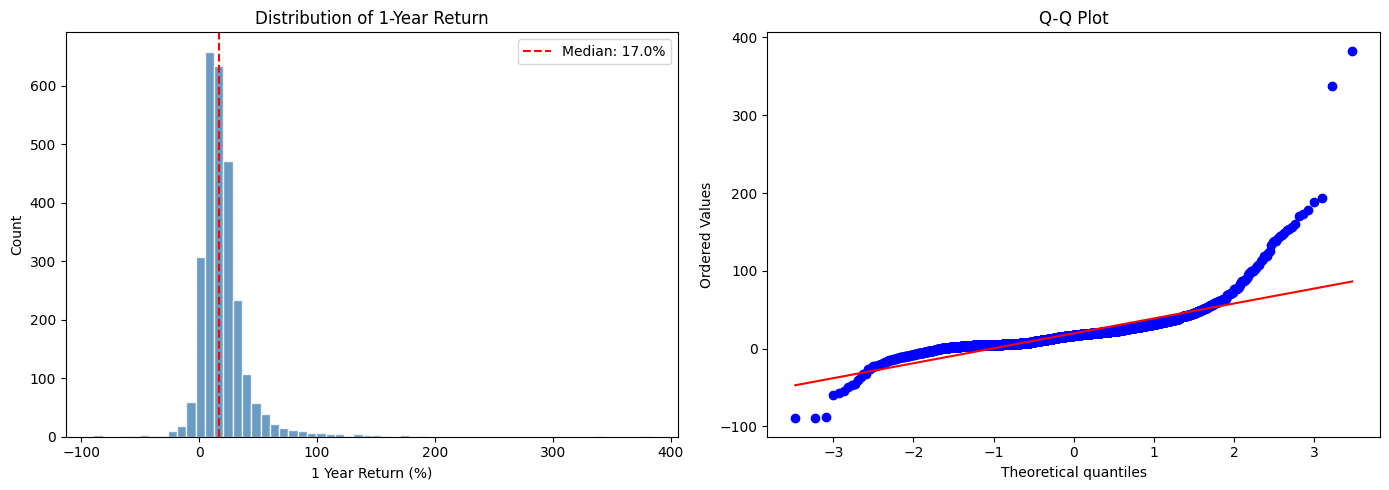

In [ ]:
# ============================================================
# CELL 9: Return 分布
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 直方图
axes[0].hist(df_model['Return_1Y'], bins=60, color='steelblue',
             edgecolor='white', alpha=0.8)
axes[0].axvline(df_model['Return_1Y'].median(), color='red',
                linestyle='--', label=f"Median: {df_model['Return_1Y'].median():.1f}%")
axes[0].set_xlabel('1 Year Return (%)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of 1-Year Return')
axes[0].legend()

# QQ图
stats.probplot(df_model['Return_1Y'].dropna(), dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()


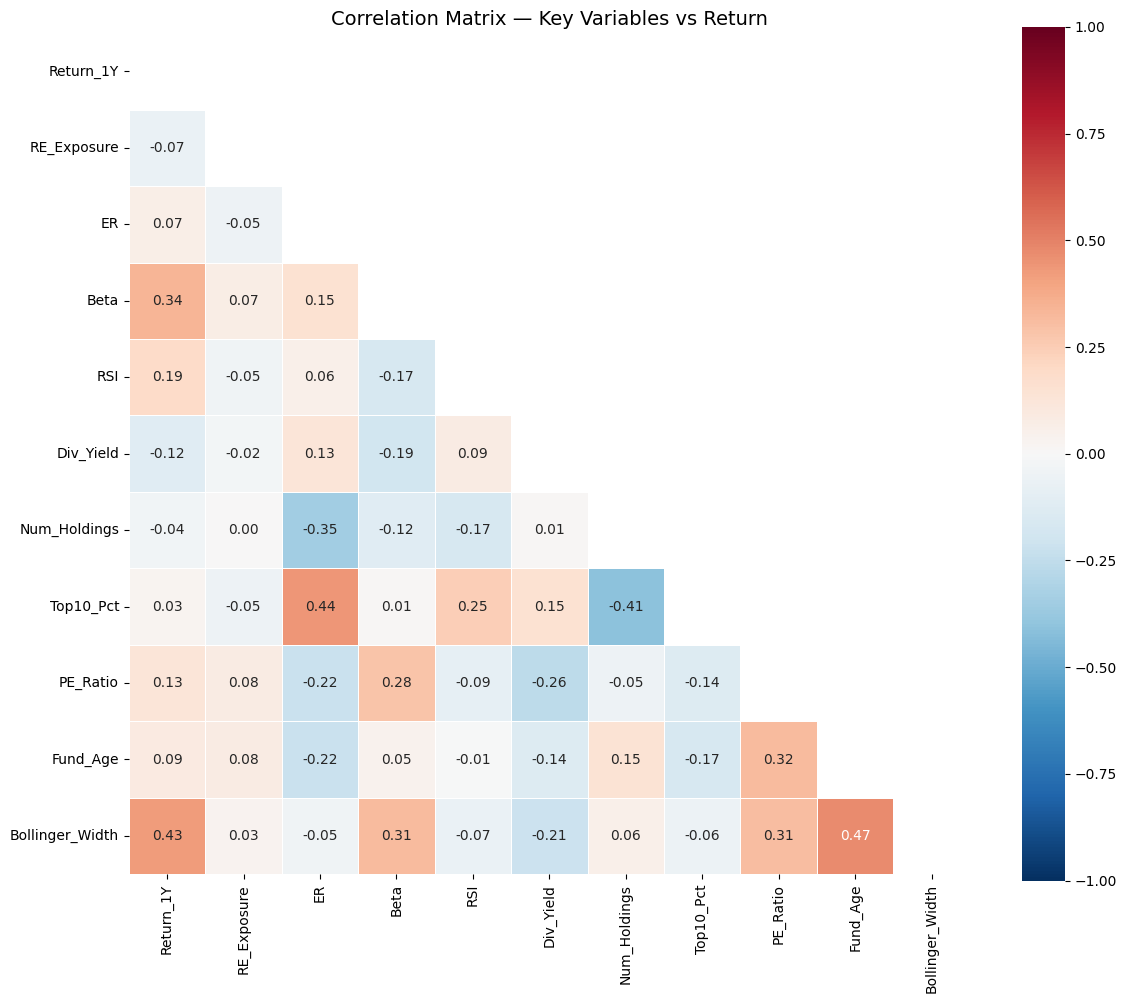


📊 与 Return_1Y 的相关系数 (Pearson):
  ➖ Div_Yield                : -0.1174
  ➖ RE_Exposure              : -0.0660
  ➖ Num_Holdings             : -0.0385
  ➕ Top10_Pct                : +0.0305
  ➕ ER                       : +0.0687
  ➕ Fund_Age                 : +0.0888
  ➕ PE_Ratio                 : +0.1274
  ➕ RSI                      : +0.1939
  ➕ Beta                     : +0.3375
  ➕ Bollinger_Width          : +0.4277


In [ ]:
# ============================================================
# CELL 10: 相关矩阵热力图
# ============================================================
corr_cols = ['Return_1Y', 'RE_Exposure', 'ER', 'Beta', 'RSI',
             'Div_Yield', 'Num_Holdings', 'Top10_Pct', 'PE_Ratio',
             'Fund_Age', 'Bollinger_Width']
corr_cols = [c for c in corr_cols if c in df_model.columns]

corr_matrix = df_model[corr_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Matrix — Key Variables vs Return', fontsize=14)
plt.tight_layout()
plt.show()

# 打印与 Return 的相关系数
print("\n📊 与 Return_1Y 的相关系数 (Pearson):")
corr_with_return = corr_matrix['Return_1Y'].drop('Return_1Y').sort_values()
for var, val in corr_with_return.items():
    direction = "➕" if val > 0 else "➖"
    print(f"  {direction} {var:25s}: {val:+.4f}")


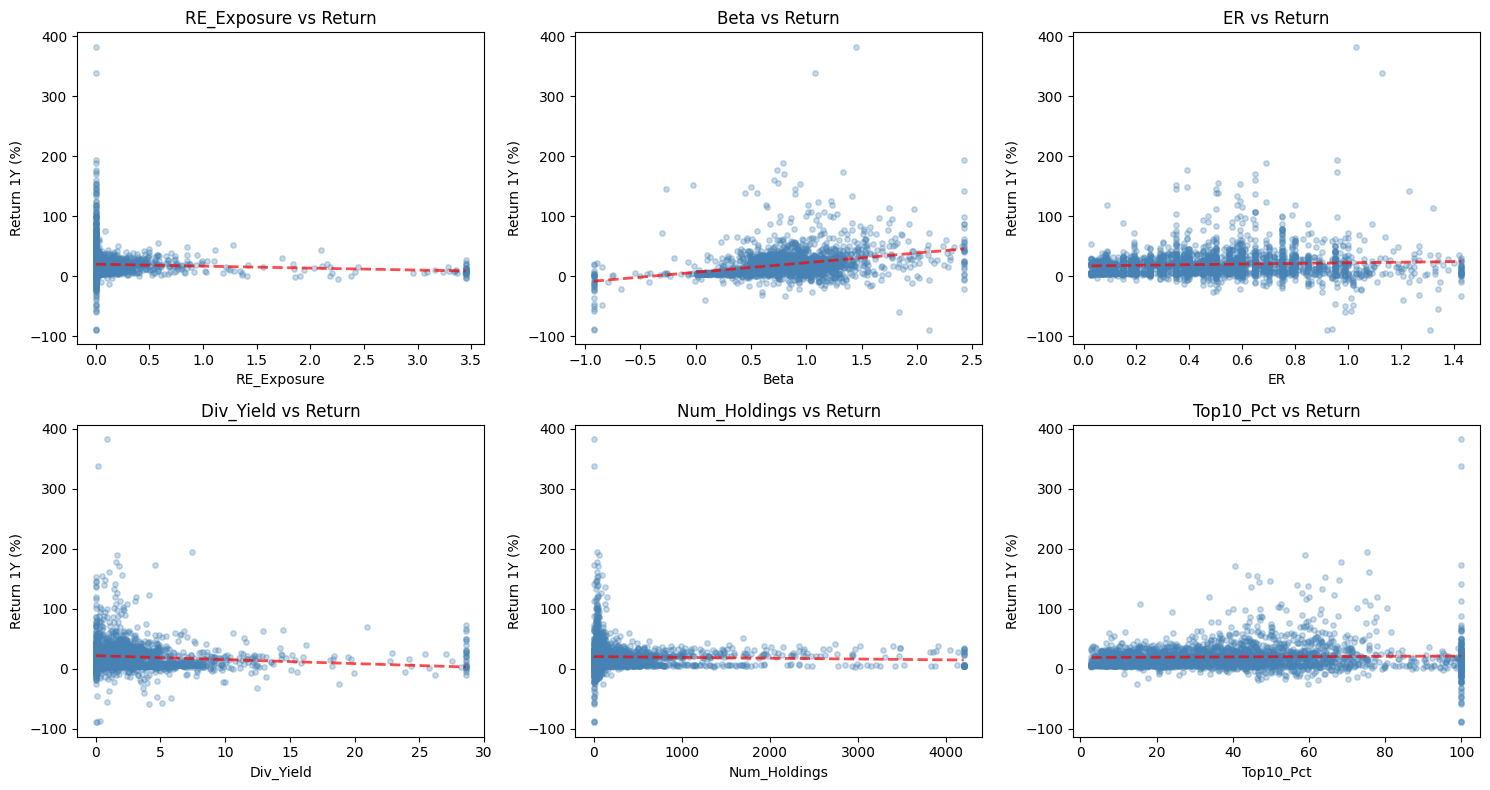

In [ ]:
# ============================================================
# CELL 11: 核心变量 vs Return 散点图
# ============================================================
scatter_vars = ['RE_Exposure', 'Beta', 'ER', 'Div_Yield',
                'Num_Holdings', 'Top10_Pct']
scatter_vars = [v for v in scatter_vars if v in df_model.columns]

n_vars = len(scatter_vars)
n_cols = 3
n_rows = (n_vars + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, var in enumerate(scatter_vars):
    ax = axes[i]
    valid = df_model[[var, 'Return_1Y']].dropna()
    ax.scatter(valid[var], valid['Return_1Y'],
               alpha=0.3, s=15, c='steelblue')

    # 加趋势线
    if len(valid) > 10:
        z = np.polyfit(valid[var], valid['Return_1Y'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(valid[var].min(), valid[var].max(), 100)
        ax.plot(x_range, p(x_range), 'r--', linewidth=2, alpha=0.7)

    ax.set_xlabel(var)
    ax.set_ylabel('Return 1Y (%)')
    ax.set_title(f'{var} vs Return')

# 隐藏多余的子图
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


In [1]:
# ============================================================
# CELL 12: OLS 回归 (基线模型)
# ============================================================

# 准备 X 和 y
feature_cols = [c for c in model_features if c in df_model.columns and c != 'Return_1Y']
X_ols = df_model[feature_cols].copy()
y_ols = df_model['Return_1Y'].copy()

# 去掉仍有 NaN 的行
valid_mask = X_ols.notna().all(axis=1) & y_ols.notna()
X_ols = X_ols[valid_mask]
y_ols = y_ols[valid_mask]

# 加常数项
X_ols_const = sm.add_constant(X_ols)

# OLS with HAC robust standard errors
ols_model = sm.OLS(y_ols, X_ols_const).fit(cov_type='HC3')

print("=" * 70)
print("OLS 回归结果 (HAC Robust SE)")
print("=" * 70)
print(ols_model.summary())

# 提取系数方向
print("\n\n📊 OLS 系数方向汇总:")
print("-" * 50)
coefs = ols_model.params.drop('const')
pvals = ols_model.pvalues.drop('const')

for var in coefs.index:
    coef = coefs[var]
    pval = pvals[var]
    sig = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.1 else ""
    direction = "positive +" if coef > 0 else "negative -"
    print(f"  {var:25s}: {coef:+10.4f}  (p={pval:.4f}) {sig} → {direction}")


NameError: name 'model_features' is not defined

Elastic Net 回归结果
最优 alpha: 0.065513
最优 l1_ratio: 0.30
R² (in-sample): 0.3230

保留的变量数: 13 / 13

📊 Elastic Net 非零系数 (标准化):
--------------------------------------------------
  Total_Assets             :  -2.8085  █████ → 负向 -
  Fund_Age                 :  -1.7597  ███ → 负向 -
  RE_Exposure              :  -1.7084  ███ → 负向 -
  Top10_Pct                :  -0.7012  █ → 负向 -
  Div_Yield                :  -0.5390  █ → 负向 -
  PE_Ratio                 :  -0.1167   → 负向 -
  Avg_Volume               :  +0.5078  █ → 正向 +
  ER                       :  +0.5170  █ → 正向 +
  Num_Holdings             :  +0.5965  █ → 正向 +
  FF_1Y                    :  +1.9626  ███ → 正向 +
  Beta                     :  +5.8317  ███████████ → 正向 +
  RSI                      :  +5.8322  ███████████ → 正向 +
  Bollinger_Width          :  +9.0865  ██████████████████ → 正向 +


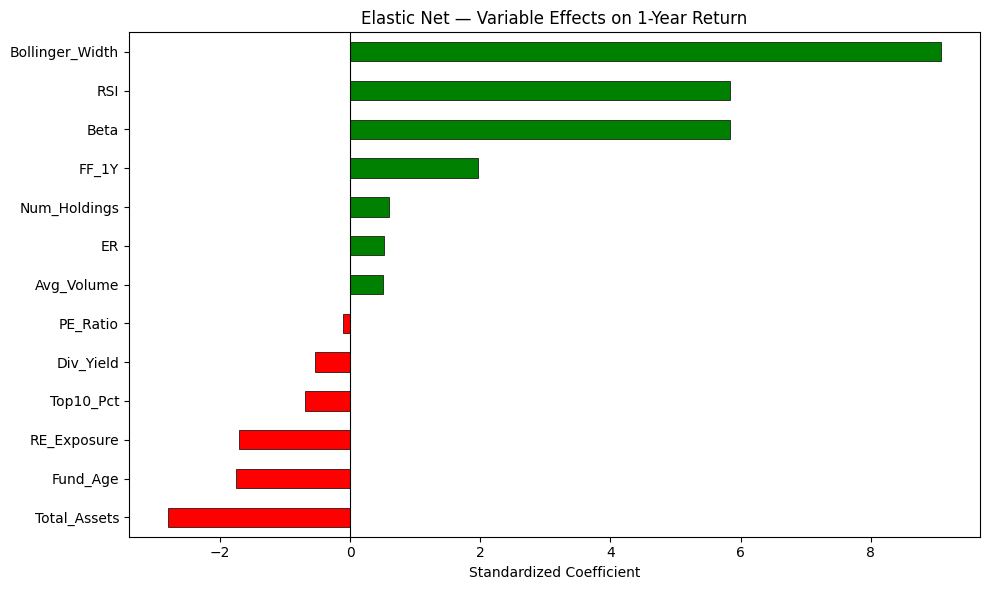

In [ ]:
# ============================================================
# CELL 13: Elastic Net 回归（带正则化的特征筛选）
# ============================================================

# 标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ols)

# Elastic Net CV
enet = ElasticNetCV(
    l1_ratio=[0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
    alphas=np.logspace(-4, 2, 50),
    cv=5,
    random_state=42,
    max_iter=10000
)
enet.fit(X_scaled, y_ols)

# 结果
print("=" * 70)
print("Elastic Net 回归结果")
print("=" * 70)
print(f"最优 alpha: {enet.alpha_:.6f}")
print(f"最优 l1_ratio: {enet.l1_ratio_:.2f}")
print(f"R² (in-sample): {enet.score(X_scaled, y_ols):.4f}")

# 提取系数
enet_coefs = pd.Series(enet.coef_, index=feature_cols)
enet_coefs = enet_coefs[enet_coefs != 0].sort_values()

print(f"\n保留的变量数: {len(enet_coefs)} / {len(feature_cols)}")
print("\n📊 Elastic Net 非零系数 (标准化):")
print("-" * 50)
for var, coef in enet_coefs.items():
    direction = "正向 +" if coef > 0 else "负向 -"
    bar = "█" * int(abs(coef) * 2)
    print(f"  {var:25s}: {coef:+8.4f}  {bar} → {direction}")

# 可视化
fig, ax = plt.subplots(figsize=(10, max(6, len(enet_coefs) * 0.4)))
colors = ['green' if c > 0 else 'red' for c in enet_coefs.values]
enet_coefs.plot(kind='barh', color=colors, ax=ax, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Standardized Coefficient')
ax.set_title('Elastic Net — Variable Effects on 1-Year Return')
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()


XGBoost 交叉验证结果
5-Fold CV R²: 0.4848 ± 0.1529
各折 R²: ['0.2113', '0.6705', '0.5123', '0.4647', '0.5653']

训练集 R²: 0.9607
训练集 RMSE: 4.55


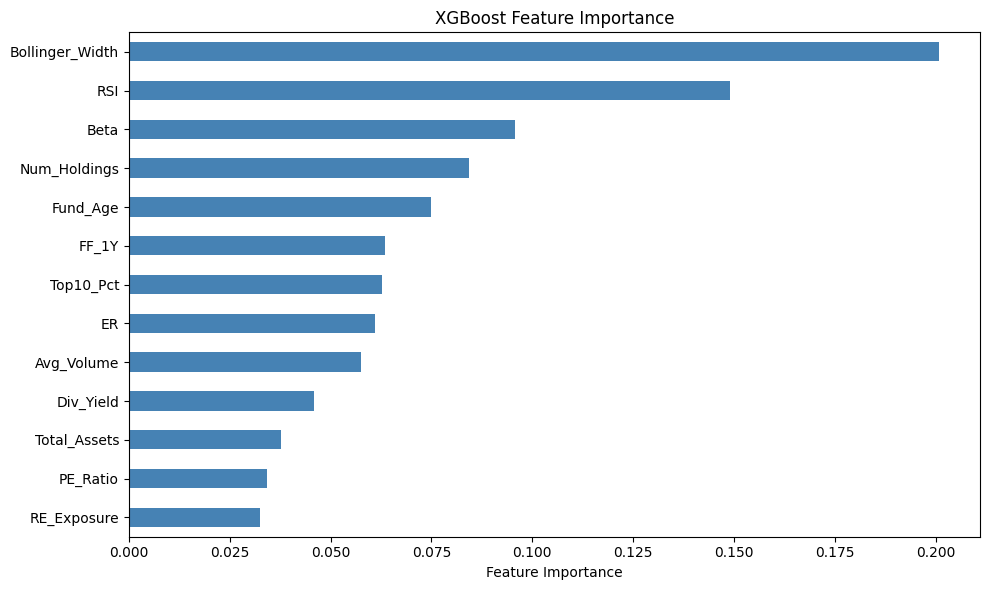

In [ ]:
# ============================================================
# CELL 14: XGBoost 模型训练
# ============================================================

xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=1,
    reg_lambda=1,
    random_state=42,
    n_jobs=-1
)

# 5-Fold CV
cv_scores = cross_val_score(xgb_model, X_ols, y_ols,
                            cv=5, scoring='r2')

print("=" * 70)
print("XGBoost 交叉验证结果")
print("=" * 70)
print(f"5-Fold CV R²: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"各折 R²: {[f'{s:.4f}' for s in cv_scores]}")

# 在全量数据上拟合（用于 SHAP）
xgb_model.fit(X_ols, y_ols)
y_pred = xgb_model.predict(X_ols)
print(f"\n训练集 R²: {r2_score(y_ols, y_pred):.4f}")
print(f"训练集 RMSE: {np.sqrt(mean_squared_error(y_ols, y_pred)):.2f}")

# 特征重要性
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, max(6, len(importance) * 0.4)))
importance.plot(kind='barh', color='steelblue', ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()


正在计算 SHAP 值，请稍等...

📊 SHAP Summary Plot — 显示每个变量对 Return 的正负影响方向


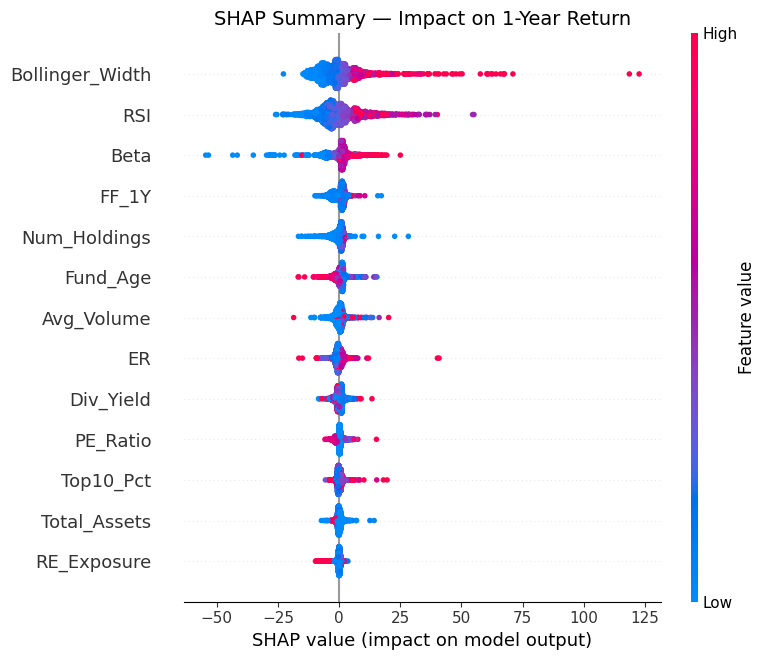

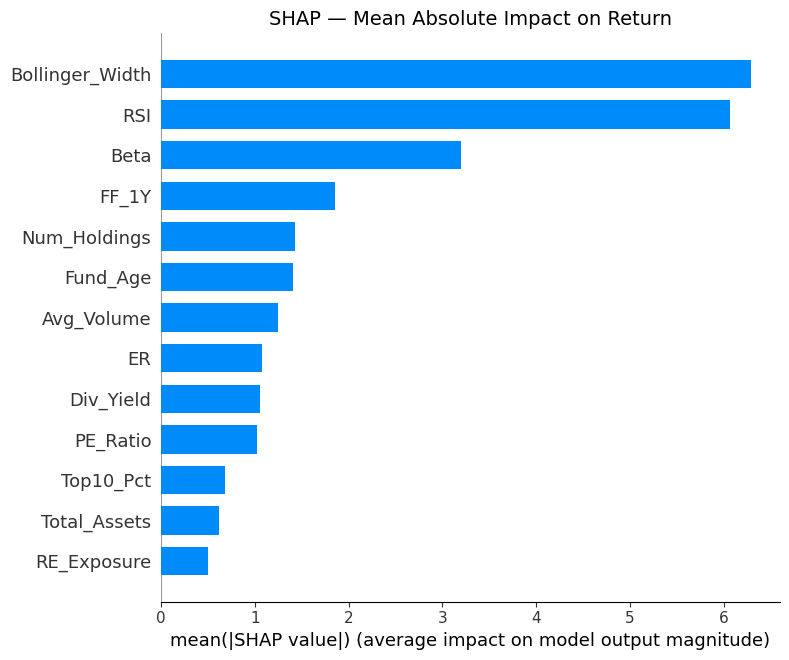

In [ ]:
# ============================================================
# CELL 15: SHAP 分析（核心：正负影响方向）
# ============================================================

print("正在计算 SHAP 值，请稍等...")

# 计算 SHAP
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_ols)

# --- SHAP Summary Plot (Beeswarm) ---
print("\n📊 SHAP Summary Plot — 显示每个变量对 Return 的正负影响方向")
fig, ax = plt.subplots(figsize=(12, max(6, len(feature_cols) * 0.4)))
shap.summary_plot(shap_values, X_ols, feature_names=feature_cols,
                  show=False, max_display=20)
plt.title('SHAP Summary — Impact on 1-Year Return', fontsize=14)
plt.tight_layout()
plt.show()

# --- SHAP Bar Plot ---
fig, ax = plt.subplots(figsize=(10, max(6, len(feature_cols) * 0.4)))
shap.summary_plot(shap_values, X_ols, feature_names=feature_cols,
                  plot_type='bar', show=False, max_display=20)
plt.title('SHAP — Mean Absolute Impact on Return', fontsize=14)
plt.tight_layout()
plt.show()


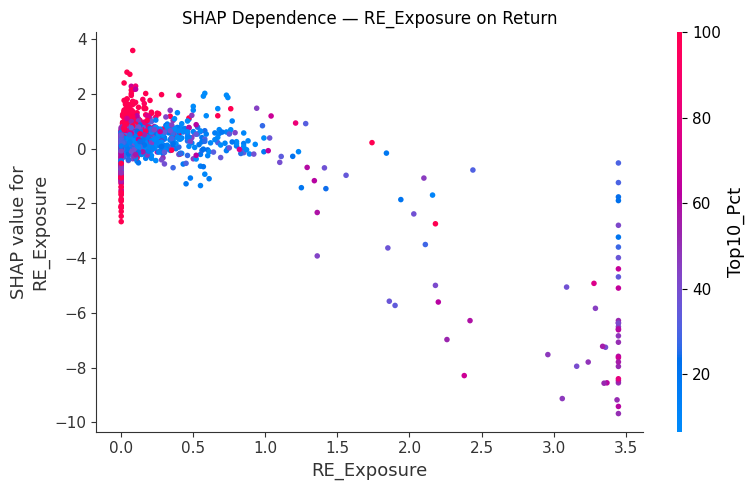

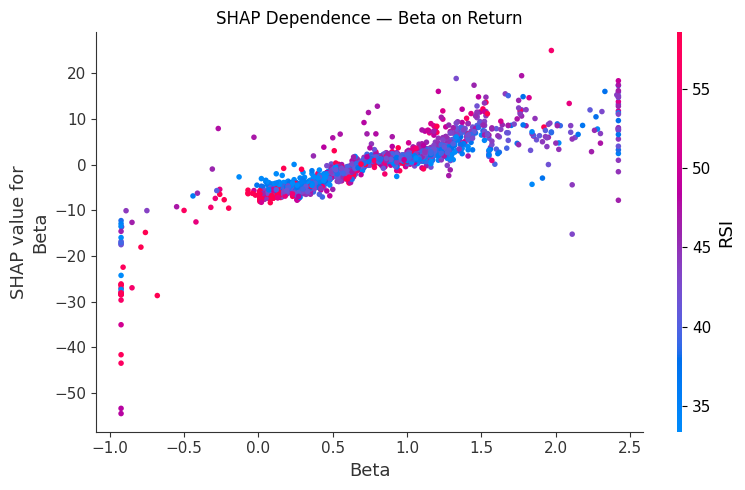

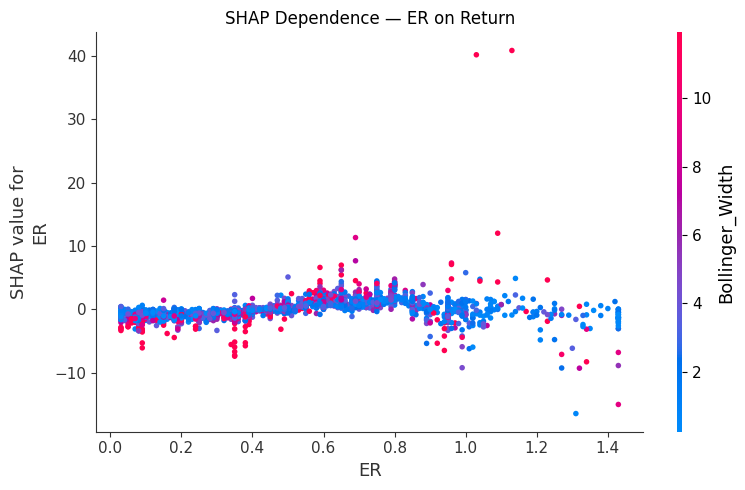

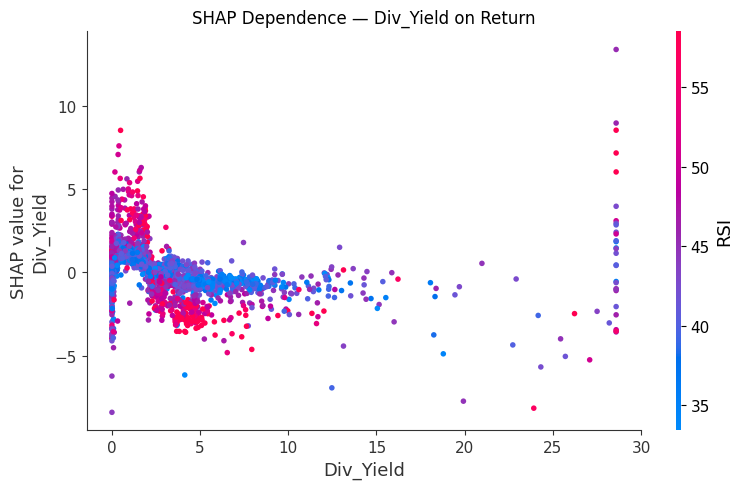

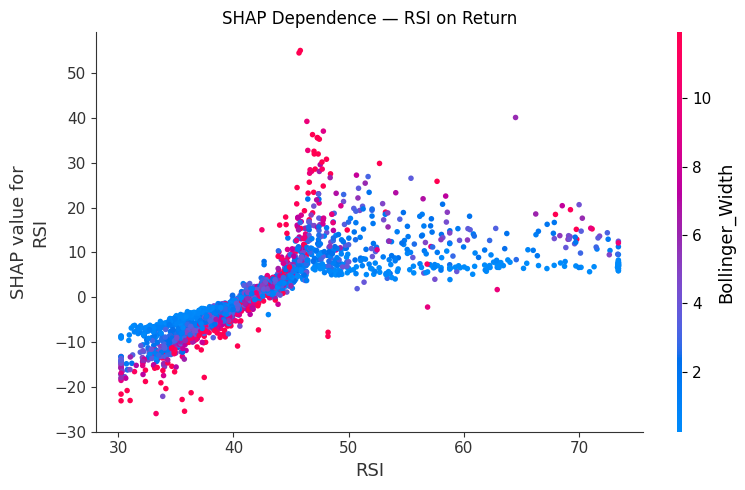

In [ ]:
# ============================================================
# CELL 16: SHAP 单变量依赖图（关键变量）
# ============================================================

key_features = ['RE_Exposure', 'Beta', 'ER', 'Div_Yield', 'RSI']
key_features = [f for f in key_features if f in feature_cols]

for feat in key_features:
    fig, ax = plt.subplots(figsize=(8, 5))
    feat_idx = feature_cols.index(feat)
    shap.dependence_plot(feat_idx, shap_values, X_ols,
                         feature_names=feature_cols, show=False, ax=ax)
    ax.set_title(f'SHAP Dependence — {feat} on Return')
    plt.tight_layout()
    plt.show()


In [ ]:
# ============================================================
# CELL 17: SHAP 平均方向汇总表
# ============================================================

shap_df = pd.DataFrame(shap_values, columns=feature_cols)

# 计算每个变量的平均 SHAP 方向
shap_summary = pd.DataFrame({
    'Mean_SHAP': shap_df.mean(),
    'Mean_Abs_SHAP': shap_df.abs().mean(),
    'Positive_Pct': (shap_df > 0).mean() * 100,
    'Direction': np.where(shap_df.mean() > 0, '正向 (+)', '负向 (-)')
}).sort_values('Mean_Abs_SHAP', ascending=False)

print("=" * 70)
print("📊 SHAP 方向汇总表")
print("=" * 70)
print(f"{'Variable':25s} {'Mean SHAP':>12s} {'|Mean SHAP|':>12s} "
      f"{'正向比例%':>10s} {'方向':>10s}")
print("-" * 70)
for idx, row in shap_summary.iterrows():
    print(f"{idx:25s} {row['Mean_SHAP']:+12.4f} {row['Mean_Abs_SHAP']:12.4f} "
          f"{row['Positive_Pct']:10.1f} {row['Direction']:>10s}")


📊 SHAP 方向汇总表
Variable                     Mean SHAP  |Mean SHAP|      正向比例%         方向
----------------------------------------------------------------------
Bollinger_Width                -0.3232       6.2883       39.7     负向 (-)
RSI                            +0.0151       6.0645       42.3     正向 (+)
Beta                           +0.1180       3.1964       65.1     正向 (+)
FF_1Y                          +0.0421       1.8601       63.3     正向 (+)
Num_Holdings                   -0.2120       1.4276       57.2     负向 (-)
Fund_Age                       +0.2555       1.4029       63.6     正向 (+)
Avg_Volume                     +0.0127       1.2454       55.1     正向 (+)
ER                             -0.0211       1.0729       45.5     负向 (-)
Div_Yield                      +0.0796       1.0579       53.3     正向 (+)
PE_Ratio                       +0.0628       1.0200       63.7     正向 (+)
Top10_Pct                      +0.0764       0.6832       49.2     正向 (+)
Total_Assets                

In [ ]:
# ============================================================
# CELL 18: PLS-SEM 数据准备
# ============================================================

# 为 SEM 准备的数据 —— 使用标准化后的变量
sem_data = df_model[['Return_1Y'] + feature_cols].dropna().copy()

# 标准化所有变量（SEM 对量纲敏感）
sem_scaler = StandardScaler()
sem_scaled = pd.DataFrame(
    sem_scaler.fit_transform(sem_data),
    columns=sem_data.columns,
    index=sem_data.index
)

print(f"SEM 数据集大小: {sem_scaled.shape}")
print(f"SEM 数据集列: {list(sem_scaled.columns)}")


SEM 数据集大小: (2706, 14)
SEM 数据集列: ['Return_1Y', 'RE_Exposure', 'ER', 'Total_Assets', 'Avg_Volume', 'PE_Ratio', 'Beta', 'RSI', 'Bollinger_Width', 'Div_Yield', 'Num_Holdings', 'Top10_Pct', 'FF_1Y', 'Fund_Age']


In [ ]:
# ============================================================
# CELL 19: PLS-SEM 模型定义与估计
# ============================================================
# 注意: semopy 主要做 CB-SEM, 对于这里的探索性分析也足够用
# 如果需要纯 PLS-SEM, 可改用 plspm (R) 或 pls_sem (Python)

# 根据可用变量动态构建模型
available_features = [c for c in feature_cols if c in sem_scaled.columns]

print("可用的特征变量:", available_features)

# ---- 定义潜变量测量模型和结构模型 ----
# 这里因为很多是单指标，用路径分析（观测变量直接连接）更实际

# 构建路径模型描述
# 核心思路:
#   Return_1Y ~ RE_Exposure + Beta + ER + Div_Yield + RSI +
#               Num_Holdings + Top10_Pct + Fund_Age + ...

# 动态构建公式
predictors = ' + '.join(available_features)
model_desc = f"""
    Return_1Y ~ {predictors}
"""

print("\n模型描述:")
print(model_desc)

# 估计模型
try:
    sem_model = semopy.Model(model_desc)
    result = sem_model.fit(sem_scaled)

    print("\n" + "=" * 70)
    print("SEM 路径分析结果")
    print("=" * 70)

    # 获取估计结果
    estimates = sem_model.inspect()
    print(estimates.to_string())

    # 模型拟合指标
    stats_result = semopy.calc_stats(sem_model)
    print("\n模型拟合指标:")
    print(stats_result.to_string())

except Exception as e:
    print(f"⚠️ semopy 路径分析遇到问题: {e}")
    print("改用 statsmodels 的 OLS 作为替代展示路径系数...")


可用的特征变量: ['RE_Exposure', 'ER', 'Total_Assets', 'Avg_Volume', 'PE_Ratio', 'Beta', 'RSI', 'Bollinger_Width', 'Div_Yield', 'Num_Holdings', 'Top10_Pct', 'FF_1Y', 'Fund_Age']

模型描述:

    Return_1Y ~ RE_Exposure + ER + Total_Assets + Avg_Volume + PE_Ratio + Beta + RSI + Bollinger_Width + Div_Yield + Num_Holdings + Top10_Pct + FF_1Y + Fund_Age


SEM 路径分析结果
         lval  op             rval  Estimate  Std. Err    z-value       p-value
0   Return_1Y   ~      RE_Exposure -0.078453  0.015958  -4.916076  8.829612e-07
1   Return_1Y   ~               ER  0.020067  0.019334   1.037904  2.993146e-01
2   Return_1Y   ~     Total_Assets -0.153437  0.027708  -5.537543  3.067436e-08
3   Return_1Y   ~       Avg_Volume  0.036062  0.021436   1.682334  9.250404e-02
4   Return_1Y   ~         PE_Ratio -0.009858  0.018502  -0.532824  5.941552e-01
5   Return_1Y   ~             Beta  0.265719  0.018028  14.739205  0.000000e+00
6   Return_1Y   ~              RSI  0.271219  0.016776  16.166849  0.000000e+00
7   Retu

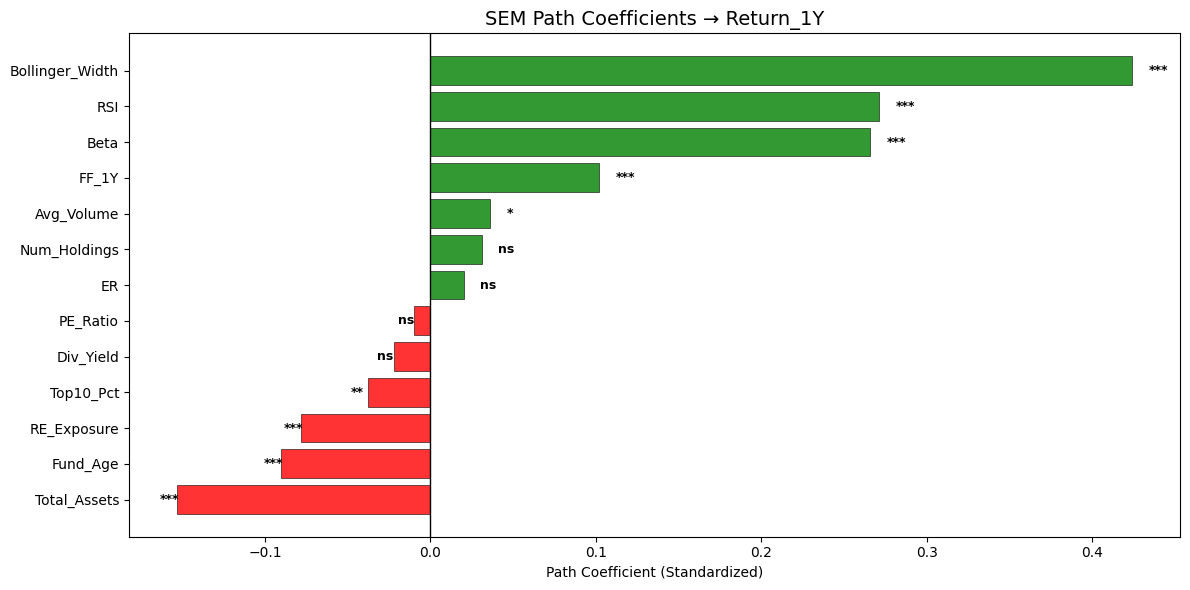


📊 SEM 路径系数正负方向汇总:
-----------------------------------------------------------------
Variable                   Coefficient    p-value   Sig  Direction
-----------------------------------------------------------------
  Bollinger_Width                +0.4241     0.0000   ***     正向 (+)
  RSI                            +0.2712     0.0000   ***     正向 (+)
  Beta                           +0.2657     0.0000   ***     正向 (+)
  FF_1Y                          +0.1021     0.0000   ***     正向 (+)
  Avg_Volume                     +0.0361     0.0925     *     正向 (+)
  Num_Holdings                   +0.0309     0.1064           正向 (+)
  ER                             +0.0201     0.2993           正向 (+)
  PE_Ratio                       -0.0099     0.5942           负向 (-)
  Div_Yield                      -0.0222     0.1881           负向 (-)
  Top10_Pct                      -0.0379     0.0488    **     负向 (-)
  RE_Exposure                    -0.0785     0.0000   ***     负向 (-)
  Fund_Age             

In [ ]:
# ============================================================
# CELL 20: SEM 路径系数可视化
# ============================================================

try:
    # 从 semopy 结果提取路径系数
    path_estimates = estimates[estimates['op'] == '~'].copy()
    path_estimates = path_estimates[['lval', 'rval', 'Estimate', 'p-value']].copy()
    path_estimates.columns = ['DV', 'IV', 'Coefficient', 'p_value']
    path_estimates = path_estimates.sort_values('Coefficient')

    # 可视化
    fig, ax = plt.subplots(figsize=(12, max(6, len(path_estimates) * 0.45)))
    colors = ['green' if c > 0 else 'red' for c in path_estimates['Coefficient']]

    bars = ax.barh(range(len(path_estimates)), path_estimates['Coefficient'],
                   color=colors, edgecolor='black', linewidth=0.5, alpha=0.8)

    ax.set_yticks(range(len(path_estimates)))
    ax.set_yticklabels(path_estimates['IV'])
    ax.set_xlabel('Path Coefficient (Standardized)')
    ax.set_title('SEM Path Coefficients → Return_1Y', fontsize=14)
    ax.axvline(0, color='black', linewidth=1)

    # 添加显著性标记
    for i, (_, row) in enumerate(path_estimates.iterrows()):
        sig = "***" if row['p_value'] < 0.01 else "**" if row['p_value'] < 0.05 else \
              "*" if row['p_value'] < 0.1 else "ns"
        ax.text(row['Coefficient'] + 0.01 * np.sign(row['Coefficient']),
                i, sig, va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # 打印汇总
    print("\n📊 SEM 路径系数正负方向汇总:")
    print("-" * 65)
    print(f"{'Variable':25s} {'Coefficient':>12s} {'p-value':>10s} {'Sig':>5s} {'Direction':>10s}")
    print("-" * 65)
    for _, row in path_estimates.sort_values('Coefficient', ascending=False).iterrows():
        sig = "***" if row['p_value'] < 0.01 else "**" if row['p_value'] < 0.05 else \
              "*" if row['p_value'] < 0.1 else ""
        direction = "正向 (+)" if row['Coefficient'] > 0 else "负向 (-)"
        print(f"  {row['IV']:25s} {row['Coefficient']:+12.4f} {row['p_value']:10.4f} "
              f"{sig:>5s} {direction:>10s}")

except Exception as e:
    print(f"⚠️ 可视化时出错: {e}")
    print("可能是 semopy 估计未收敛，建议减少变量或检查数据。")


In [ ]:
# ============================================================
# CELL 21: 带中介效应的 SEM（高级版）
# ============================================================
# 测试: RE_Exposure → Beta (Risk) → Return
#        RE_Exposure → Top10_Pct (Concentration) → Return

mediation_vars = ['RE_Exposure', 'Beta', 'Top10_Pct', 'Return_1Y']
mediation_vars = [v for v in mediation_vars if v in sem_scaled.columns]

if len(mediation_vars) == 4:
    mediation_desc = """
        Beta ~ RE_Exposure
        Top10_Pct ~ RE_Exposure
        Return_1Y ~ RE_Exposure + Beta + Top10_Pct + ER + Div_Yield + Fund_Age
    """

    print("中介效应模型:")
    print(mediation_desc)

    try:
        med_model = semopy.Model(mediation_desc)
        med_result = med_model.fit(sem_scaled)
        med_estimates = med_model.inspect()

        print("\n" + "=" * 70)
        print("中介效应 SEM 结果")
        print("=" * 70)
        print(med_estimates.to_string())

        # 提取直接效应和间接效应
        paths = med_estimates[med_estimates['op'] == '~']
        print("\n📊 路径效应分解:")
        for _, row in paths.iterrows():
            sig = "***" if row['p-value'] < 0.01 else "**" if row['p-value'] < 0.05 else \
                  "*" if row['p-value'] < 0.1 else ""
            print(f"  {row['rval']:20s} → {row['lval']:15s}: "
                  f"{row['Estimate']:+.4f} {sig}")

    except Exception as e:
        print(f"⚠️ 中介模型出错: {e}")
else:
    print("⚠️ 中介效应所需变量不全，跳过此步。")


中介效应模型:

        Beta ~ RE_Exposure
        Top10_Pct ~ RE_Exposure
        Return_1Y ~ RE_Exposure + Beta + Top10_Pct + ER + Div_Yield + Fund_Age
    

中介效应 SEM 结果
         lval  op         rval  Estimate  Std. Err    z-value       p-value
0        Beta   ~  RE_Exposure  0.073744  0.019175   3.845937  1.200926e-04
1   Top10_Pct   ~  RE_Exposure -0.049762  0.019203  -2.591366  9.559581e-03
2   Return_1Y   ~  RE_Exposure -0.095266  0.018040  -5.280682  1.287041e-07
3   Return_1Y   ~         Beta  0.326029  0.017943  18.169840  0.000000e+00
4   Return_1Y   ~    Top10_Pct  0.032443  0.017917   1.810725  7.018346e-02
5   Return_1Y   ~           ER  0.025864  0.018449   1.401964  1.609261e-01
6   Return_1Y   ~    Div_Yield -0.054293  0.018163  -2.989164  2.797418e-03
7   Return_1Y   ~     Fund_Age  0.085583  0.018510   4.623607  3.771237e-06
8        Beta  ~~         Beta  0.994898  0.027048  36.783148  0.000000e+00
9   Top10_Pct  ~~    Top10_Pct  0.997850  0.027128  36.783148  0.000000e+00

因果发现数据维度: (2706, 9)
使用变量: ['Return_1Y', 'RE_Exposure', 'ER', 'Beta', 'RSI', 'Div_Yield', 'Top10_Pct', 'Num_Holdings', 'Fund_Age']

PC Algorithm 因果发现


  0%|          | 0/9 [00:00<?, ?it/s]


PC Algorithm 因果图:


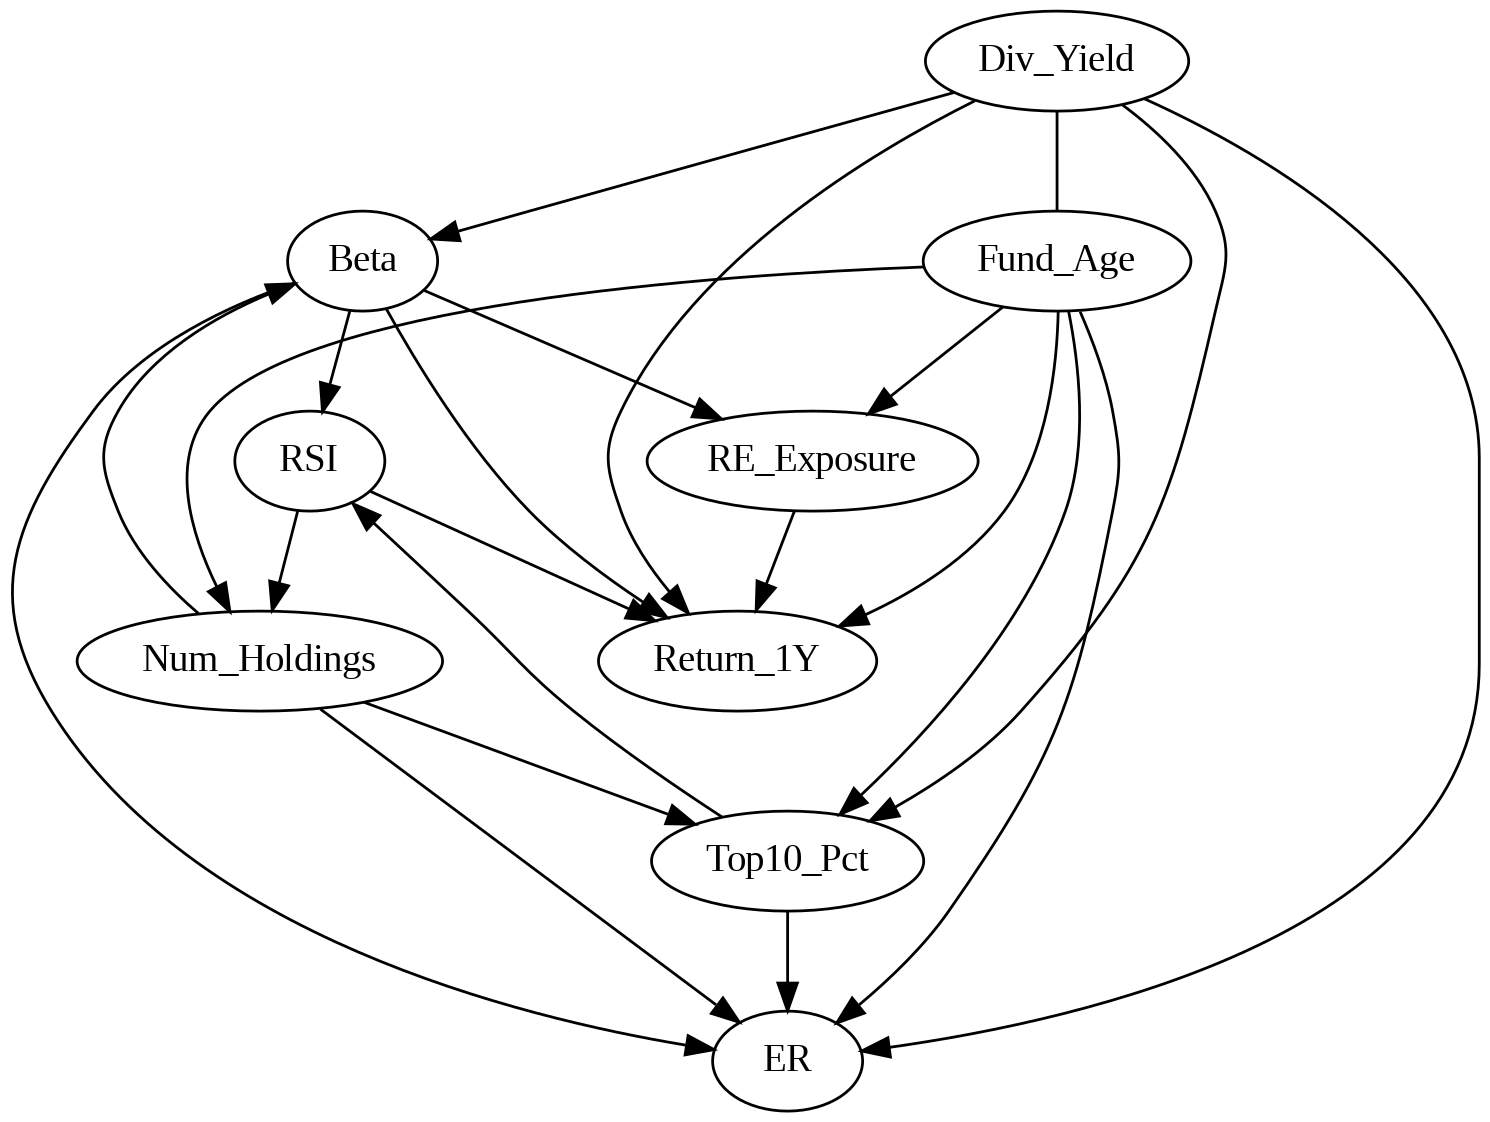


邻接矩阵:
              Return_1Y  RE_Exposure  ER  Beta  RSI  Div_Yield  Top10_Pct  \
Return_1Y             0            1   0     1    1          1          0   
RE_Exposure          -1            0   0     1    0          0          0   
ER                    0            0   0     1    0          1          1   
Beta                 -1           -1  -1     0   -1          1          0   
RSI                  -1            0   0     1    0          0          1   
Div_Yield            -1            0  -1    -1    0          0         -1   
Top10_Pct             0            0  -1     0   -1          1          0   
Num_Holdings          0            0  -1    -1    1          0         -1   
Fund_Age             -1           -1  -1     0    0         -1         -1   

              Num_Holdings  Fund_Age  
Return_1Y                0         1  
RE_Exposure              0         1  
ER                       1         1  
Beta                     1         0  
RSI                     -1 

In [ ]:
# ============================================================
# CELL 22: Causal Discovery — PC Algorithm
# ============================================================

# 选择少量关键变量做因果发现（变量太多因果图会很乱）
causal_vars = [
    'Return_1Y', 'RE_Exposure', 'ER', 'Beta', 'RSI',
    'Div_Yield', 'Top10_Pct', 'Num_Holdings', 'Fund_Age'
]
causal_vars = [v for v in causal_vars if v in df_model.columns]

causal_data = df_model[causal_vars].dropna()

print(f"因果发现数据维度: {causal_data.shape}")
print(f"使用变量: {causal_vars}")

# 标准化
causal_scaled = StandardScaler().fit_transform(causal_data)

# ---- PC Algorithm ----
print("\n" + "=" * 70)
print("PC Algorithm 因果发现")
print("=" * 70)

try:
    cg_pc = pc(
        causal_scaled,
        alpha=0.05,         # 显著性水平
        indep_test='fisherz', # Fisher Z 独立性检验
        stable=True,
        uc_rule=0,           # 0: 默认 orientation rule
        uc_priority=2        # 优先级
    )

    # 可视化因果图
    print("\nPC Algorithm 因果图:")
    labels = causal_vars

    # 使用 causal-learn 内置的可视化
    from causallearn.utils.GraphUtils import GraphUtils
    pdy = GraphUtils.to_pydot(cg_pc.G, labels=labels)

    # 保存为图片
    pdy.write_png('causal_pc.png')

    from IPython.display import Image, display
    display(Image('causal_pc.png'))

    # 打印邻接矩阵
    adj_matrix = cg_pc.G.graph
    print("\n邻接矩阵:")
    adj_df = pd.DataFrame(adj_matrix, index=labels, columns=labels)
    print(adj_df)

    # 解释边
    print("\n📊 发现的边（因果/关联关系）:")
    print("-" * 50)
    for i in range(len(labels)):
        for j in range(i + 1, len(labels)):
            if adj_matrix[i, j] != 0 or adj_matrix[j, i] != 0:
                if adj_matrix[i, j] == -1 and adj_matrix[j, i] == 1:
                    print(f"  {labels[i]:20s} → {labels[j]}")
                elif adj_matrix[i, j] == 1 and adj_matrix[j, i] == -1:
                    print(f"  {labels[j]:20s} → {labels[i]}")
                elif adj_matrix[i, j] == -1 and adj_matrix[j, i] == -1:
                    print(f"  {labels[i]:20s} ↔ {labels[j]}  (undirected)")
                else:
                    print(f"  {labels[i]:20s} --- {labels[j]}  "
                          f"(edge type: {adj_matrix[i,j]}, {adj_matrix[j,i]})")

except Exception as e:
    print(f"⚠️ PC Algorithm 出错: {e}")
    import traceback
    traceback.print_exc()


GES (Greedy Equivalence Search) 因果发现

GES 因果图:


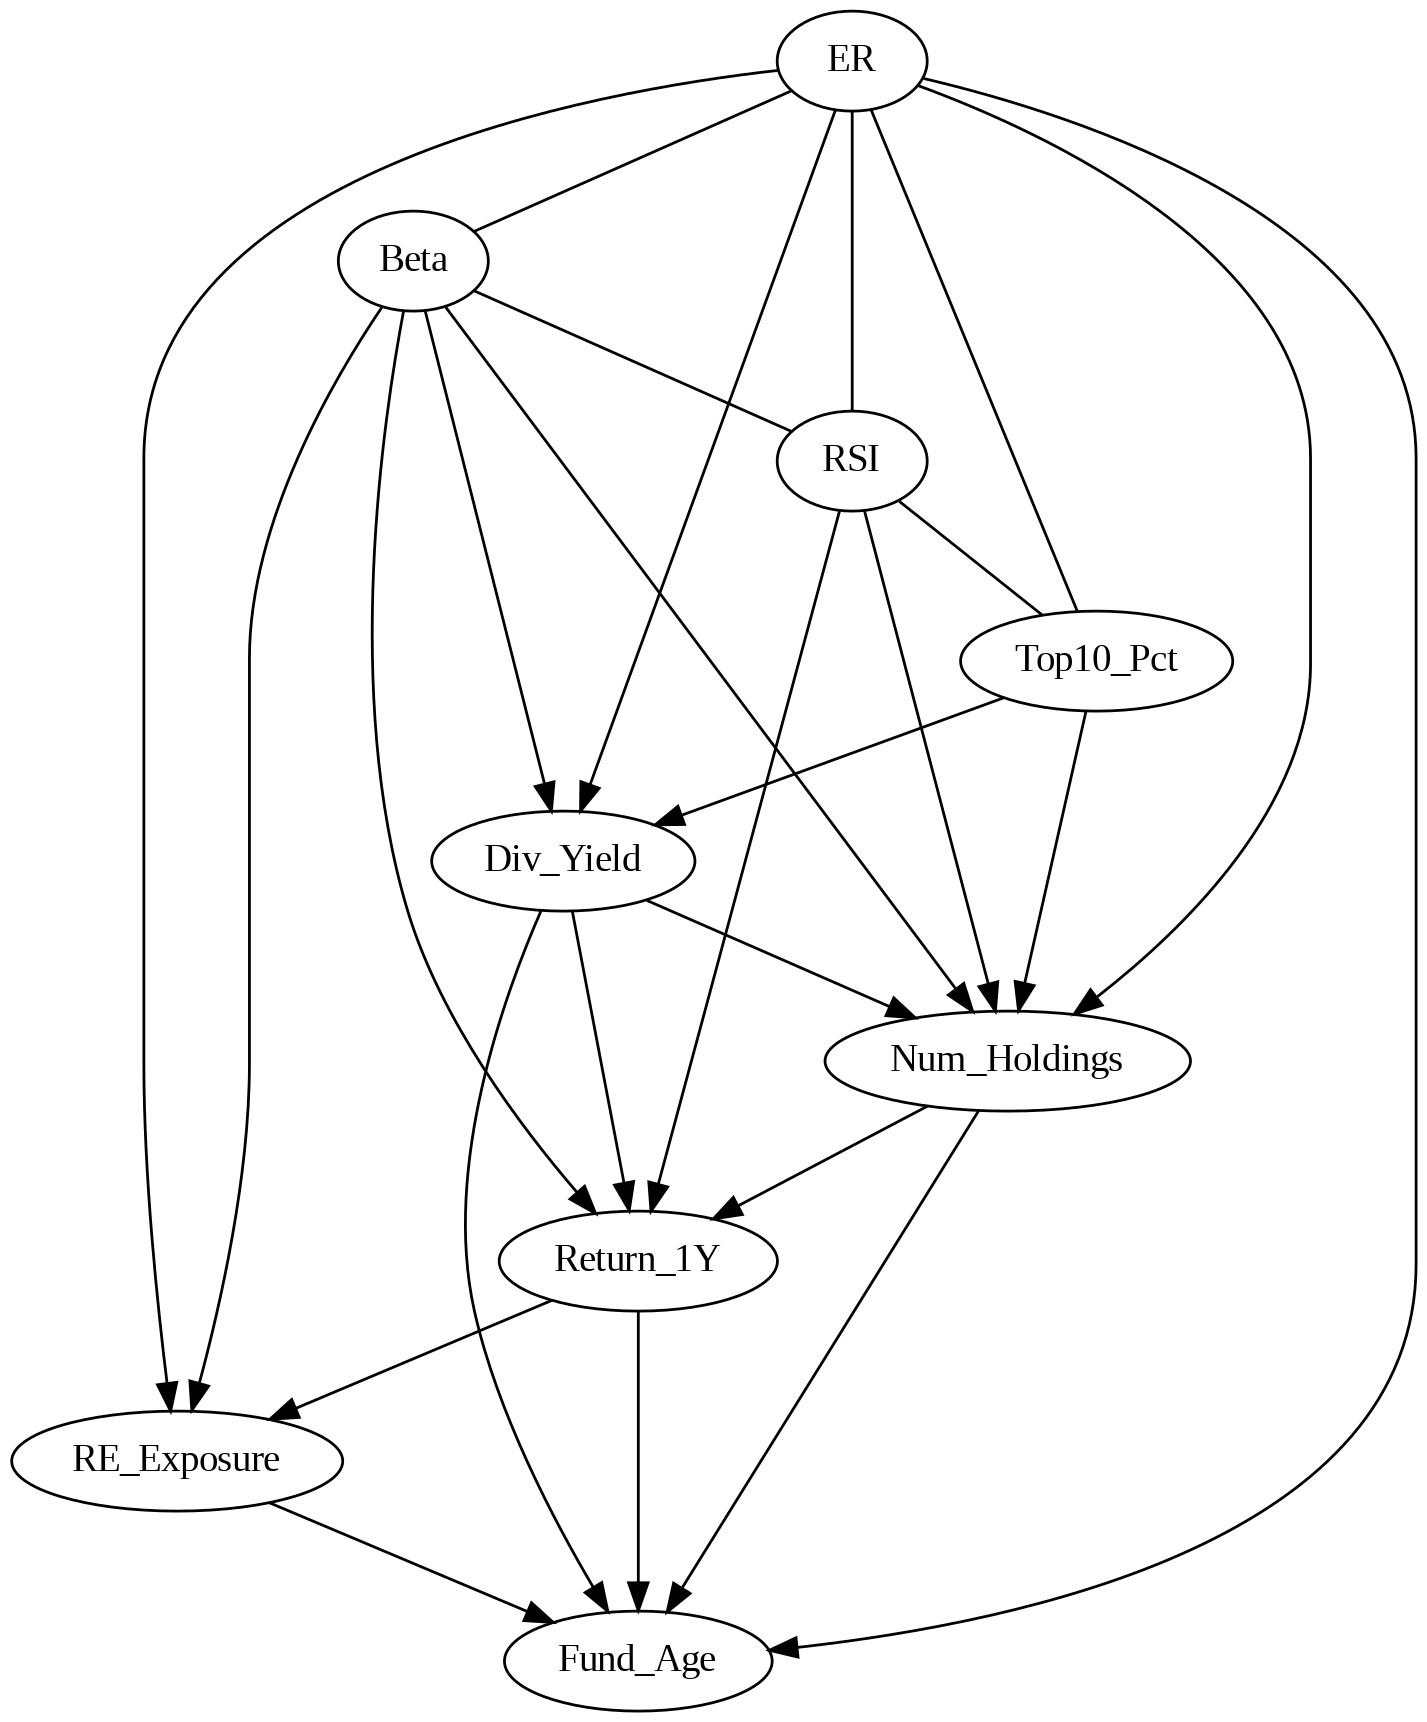


📊 GES 发现的边:
--------------------------------------------------
  Return_1Y            → RE_Exposure
  Beta                 → Return_1Y
  RSI                  → Return_1Y
  Div_Yield            → Return_1Y
  Num_Holdings         → Return_1Y
  Return_1Y            → Fund_Age
  ER                   → RE_Exposure
  Beta                 → RE_Exposure
  RE_Exposure          → Fund_Age
  ER                   ↔ Beta
  ER                   ↔ RSI
  ER                   → Div_Yield
  ER                   ↔ Top10_Pct
  ER                   → Num_Holdings
  ER                   → Fund_Age
  Beta                 ↔ RSI
  Beta                 → Div_Yield
  Beta                 → Num_Holdings
  RSI                  ↔ Top10_Pct
  RSI                  → Num_Holdings
  Top10_Pct            → Div_Yield
  Div_Yield            → Num_Holdings
  Div_Yield            → Fund_Age
  Top10_Pct            → Num_Holdings
  Num_Holdings         → Fund_Age


In [ ]:
# ============================================================
# CELL 23: Causal Discovery — GES (Greedy Equivalence Search)
# ============================================================

print("=" * 70)
print("GES (Greedy Equivalence Search) 因果发现")
print("=" * 70)

try:
    # GES
    record = ges(
        causal_scaled,
        score_func='local_score_BIC'  # BIC 评分
    )

    ges_graph = record['G']

    # 可视化
    print("\nGES 因果图:")
    pdy_ges = GraphUtils.to_pydot(ges_graph, labels=causal_vars)
    pdy_ges.write_png('causal_ges.png')
    display(Image('causal_ges.png'))

    # 打印边
    adj_ges = ges_graph.graph
    print("\n📊 GES 发现的边:")
    print("-" * 50)
    for i in range(len(causal_vars)):
        for j in range(i + 1, len(causal_vars)):
            if adj_ges[i, j] != 0 or adj_ges[j, i] != 0:
                if adj_ges[i, j] == -1 and adj_ges[j, i] == 1:
                    print(f"  {causal_vars[i]:20s} → {causal_vars[j]}")
                elif adj_ges[i, j] == 1 and adj_ges[j, i] == -1:
                    print(f"  {causal_vars[j]:20s} → {causal_vars[i]}")
                elif adj_ges[i, j] == -1 and adj_ges[j, i] == -1:
                    print(f"  {causal_vars[i]:20s} ↔ {causal_vars[j]}")
                else:
                    print(f"  {causal_vars[i]:20s} --- {causal_vars[j]}")

except Exception as e:
    print(f"⚠️ GES 出错: {e}")
    import traceback
    traceback.print_exc()


In [ ]:
# ============================================================
# CELL 24: 对比两种因果发现结果
# ============================================================

print("=" * 70)
print("📊 因果发现结果对比汇总")
print("=" * 70)

print("""
⚠️ 重要提醒：
  1. 横截面数据的因果发现只是"探索性"的
  2. 结果仅表示"在这组数据统计相关结构中的可能方向"
  3. 不能直接等同于"真实因果关系"
  4. 如需更强的因果结论，需要：
     - 面板/时间序列数据
     - 自然实验/工具变量
     - 或领域专家知识约束

建议解读方式:
  - PC 和 GES 一致发现的边 → 较可信
  - 只有一个算法发现的边 → 需谨慎
  - 与领域知识矛盾的边 → 需要深入考虑
""")


📊 因果发现结果对比汇总

⚠️ 重要提醒：
  1. 横截面数据的因果发现只是"探索性"的
  2. 结果仅表示"在这组数据统计相关结构中的可能方向"
  3. 不能直接等同于"真实因果关系"
  4. 如需更强的因果结论，需要：
     - 面板/时间序列数据
     - 自然实验/工具变量
     - 或领域专家知识约束

建议解读方式:
  - PC 和 GES 一致发现的边 → 较可信
  - 只有一个算法发现的边 → 需谨慎
  - 与领域知识矛盾的边 → 需要深入考虑



In [ ]:
# ============================================================
# CELL 25: 所有模型结果综合对比表
# ============================================================

print("=" * 80)
print("📊 综合结果汇总 — 各模型对 Return_1Y 的变量影响方向")
print("=" * 80)

results = pd.DataFrame(index=feature_cols)

# 1) OLS 系数方向
try:
    ols_coefs = ols_model.params.drop('const')
    ols_pvals = ols_model.pvalues.drop('const')
    results['OLS_Coef'] = ols_coefs
    results['OLS_pval'] = ols_pvals
    results['OLS_Dir'] = np.where(ols_coefs > 0, '+', '-')
    results['OLS_Sig'] = np.where(ols_pvals < 0.05, '✓', '')
except:
    pass

# 2) Elastic Net 系数方向
try:
    enet_full = pd.Series(enet.coef_, index=feature_cols)
    results['ENet_Coef'] = enet_full
    results['ENet_Dir'] = np.where(enet_full > 0, '+',
                                    np.where(enet_full < 0, '-', '0'))
except:
    pass

# 3) SHAP 平均方向
try:
    shap_mean = pd.DataFrame(shap_values, columns=feature_cols).mean()
    results['SHAP_Mean'] = shap_mean
    results['SHAP_Dir'] = np.where(shap_mean > 0, '+', '-')
except:
    pass

# 4) SEM 路径系数方向
try:
    sem_paths = estimates[estimates['op'] == '~'][['rval', 'Estimate', 'p-value']]
    sem_paths = sem_paths.set_index('rval')
    results['SEM_Coef'] = sem_paths['Estimate']
    results['SEM_pval'] = sem_paths['p-value']
    results['SEM_Dir'] = np.where(sem_paths['Estimate'] > 0, '+', '-')
except:
    pass

# 汇总打印
print(f"\n{'Variable':25s} | {'OLS':>5s} | {'ENet':>5s} | {'SHAP':>5s} | {'SEM':>5s} | 方向一致?")
print("-" * 80)

for var in results.index:
    dirs = []
    ols_d = results.loc[var, 'OLS_Dir'] if 'OLS_Dir' in results.columns else '?'
    enet_d = results.loc[var, 'ENet_Dir'] if 'ENet_Dir' in results.columns else '?'
    shap_d = results.loc[var, 'SHAP_Dir'] if 'SHAP_Dir' in results.columns else '?'
    sem_d = results.loc[var, 'SEM_Dir'] if 'SEM_Dir' in results.columns else '?'

    # 判断一致性
    valid_dirs = [d for d in [ols_d, enet_d, shap_d, sem_d]
                  if d in ['+', '-'] and not pd.isna(d)]
    if len(valid_dirs) > 0:
        consistent = "✅ 一致" if len(set(valid_dirs)) == 1 else "⚠️ 不一致"
    else:
        consistent = "?"

    print(f"  {var:25s} | {ols_d:>5s} | {enet_d:>5s} | {shap_d:>5s} | "
          f"{sem_d:>5s} | {consistent}")


📊 综合结果汇总 — 各模型对 Return_1Y 的变量影响方向

Variable                  |   OLS |  ENet |  SHAP |   SEM | 方向一致?
--------------------------------------------------------------------------------
  RE_Exposure               |     - |     - |     - |     - | ✅ 一致
  ER                        |     + |     + |     - |     + | ⚠️ 不一致
  Total_Assets              |     - |     - |     - |     - | ✅ 一致
  Avg_Volume                |     + |     + |     + |     + | ✅ 一致
  PE_Ratio                  |     - |     - |     + |     - | ⚠️ 不一致
  Beta                      |     + |     + |     + |     + | ✅ 一致
  RSI                       |     + |     + |     + |     + | ✅ 一致
  Bollinger_Width           |     + |     + |     - |     + | ⚠️ 不一致
  Div_Yield                 |     - |     - |     + |     - | ⚠️ 不一致
  Num_Holdings              |     + |     + |     - |     + | ⚠️ 不一致
  Top10_Pct                 |     - |     - |     + |     - | ⚠️ 不一致
  FF_1Y                     |     + |     + |     + |     + | ✅ 一致
  

In [ ]:
# ============================================================
# CELL 26: 最终结论输出
# ============================================================

print("\n" + "=" * 80)
print("🎯 研究结论汇总")
print("=" * 80)

print("""
1. 分析方法:
   - OLS 回归 (基线, 线性方向)
   - Elastic Net (正则化特征筛选)
   - XGBoost + SHAP (非线性, 局部影响方向)
   - SEM 路径分析 (结构关系)
   - PC / GES 因果发现 (探索性因果方向)

2. 核心发现 (请根据实际输出填写):
   - Revenue Exposure to Affordable Real Estate 对 Return 的影响方向: [看上表]
   - 最重要的影响因素 (SHAP 排序): [看 SHAP bar plot]
   - 模型一致性: 四种方法方向一致的变量 → 结论最可靠

3. 方法论注意:
   ⚠️ 这是横截面分析，不是严格因果推断
   ⚠️ 变量之间可能存在反向因果和遗漏变量偏差
   ⚠️ 建议后续补充时间序列维度以增强因果结论

4. 建议后续:
   - 分不同 return 周期重复分析 (1M / 3Y / 5Y)
   - 分不同样本子集 (地产主题 / 非地产 / 去杠杆)
   - 补充面板数据做动态因果分析
""")



🎯 研究结论汇总

1. 分析方法:
   - OLS 回归 (基线, 线性方向)
   - Elastic Net (正则化特征筛选)
   - XGBoost + SHAP (非线性, 局部影响方向)
   - SEM 路径分析 (结构关系)
   - PC / GES 因果发现 (探索性因果方向)

2. 核心发现 (请根据实际输出填写):
   - Revenue Exposure to Affordable Real Estate 对 Return 的影响方向: [看上表]
   - 最重要的影响因素 (SHAP 排序): [看 SHAP bar plot]
   - 模型一致性: 四种方法方向一致的变量 → 结论最可靠

3. 方法论注意:
   ⚠️ 这是横截面分析，不是严格因果推断
   ⚠️ 变量之间可能存在反向因果和遗漏变量偏差
   ⚠️ 建议后续补充时间序列维度以增强因果结论

4. 建议后续:
   - 分不同 return 周期重复分析 (1M / 3Y / 5Y)
   - 分不同样本子集 (地产主题 / 非地产 / 去杠杆)
   - 补充面板数据做动态因果分析



In [ ]:
# ============================================================
# CELL 27: 保存结果
# ============================================================

# 保存综合结果表
try:
    results.to_csv('analysis_results_summary.csv')
    print("✅ 结果已保存为 analysis_results_summary.csv")
    files.download('analysis_results_summary.csv')
except:
    print("结果表保存失败，可手动复制上方输出")

# 保存清洗后的数据
try:
    df_model.to_csv('cleaned_etf_data.csv', index=False)
    print("✅ 清洗后数据已保存为 cleaned_etf_data.csv")
    files.download('cleaned_etf_data.csv')
except:
    pass

print("\n🎉 全部分析完成！")


✅ 结果已保存为 analysis_results_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ 清洗后数据已保存为 cleaned_etf_data.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 全部分析完成！


<Axes: >

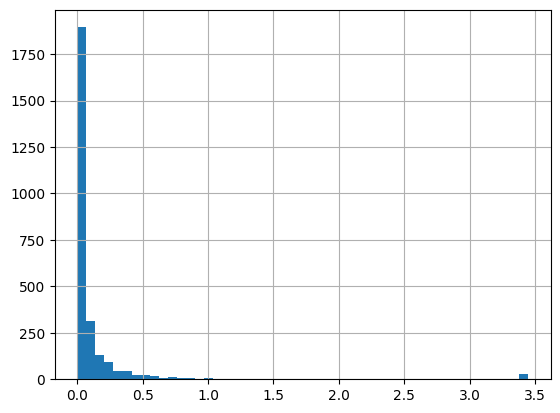

In [ ]:
# 建议补充运行：
df_model['RE_Exposure'].describe()
(df_model['RE_Exposure'] > 0).sum()
(df_model['RE_Exposure'] > 0.5).sum()
(df_model['RE_Exposure'] > 1.0).sum()
df_model['RE_Exposure'].hist(bins=50)

count    2706.000000
mean        0.139529
std         0.461973
min         0.000000
25%         0.000000
50%         0.000000
75%         0.090000
max         3.449500
Name: RE_Exposure, dtype: float64

RE_Exposure = 0 的ETF数: 1478
RE_Exposure > 0 的ETF数: 1228
RE_Exposure > 0.5 的ETF数: 151
RE_Exposure > 1.0 的ETF数: 74
RE_Exposure > 2.0 的ETF数: 51


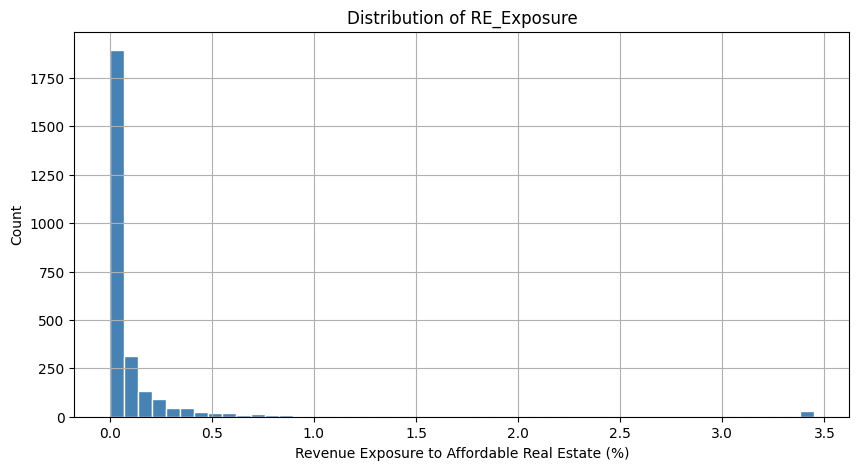

In [ ]:
# 直接在 notebook 中运行
print(df_model['RE_Exposure'].describe())
print(f"\nRE_Exposure = 0 的ETF数: {(df_model['RE_Exposure'] == 0).sum()}")
print(f"RE_Exposure > 0 的ETF数: {(df_model['RE_Exposure'] > 0).sum()}")
print(f"RE_Exposure > 0.5 的ETF数: {(df_model['RE_Exposure'] > 0.5).sum()}")
print(f"RE_Exposure > 1.0 的ETF数: {(df_model['RE_Exposure'] > 1.0).sum()}")
print(f"RE_Exposure > 2.0 的ETF数: {(df_model['RE_Exposure'] > 2.0).sum()}")

fig, ax = plt.subplots(figsize=(10, 5))
df_model['RE_Exposure'].hist(bins=50, ax=ax, color='steelblue', edgecolor='white')
ax.set_xlabel('Revenue Exposure to Affordable Real Estate (%)')
ax.set_ylabel('Count')
ax.set_title('Distribution of RE_Exposure')
plt.show()

In [ ]:
# 按 RE_Exposure 是否 > 0 分组
df_model['RE_Group'] = np.where(df_model['RE_Exposure'] > 0, 'Has Exposure', 'No Exposure')

# 比较两组的关键指标
compare_cols = ['Return_1Y', 'Beta', 'ER', 'Div_Yield', 'Total_Assets', 'FF_1Y']
group_stats = df_model.groupby('RE_Group')[compare_cols].agg(['mean', 'median', 'count'])
print(group_stats)

# t-test
from scipy.stats import ttest_ind
for col in compare_cols:
    g1 = df_model[df_model['RE_Group'] == 'Has Exposure'][col].dropna()
    g2 = df_model[df_model['RE_Group'] == 'No Exposure'][col].dropna()
    t, p = ttest_ind(g1, g2)
    print(f"{col:20s}: t={t:.3f}, p={p:.4f}")

              Return_1Y                   Beta                     ER         \
                   mean median count      mean median count      mean median   
RE_Group                                                                       
Has Exposure  17.307101  17.79  1228  0.784517   0.85  1228  0.399709   0.35   
No Exposure   21.570920  16.01  1478  0.833777   0.87  1478  0.546356   0.54   

                   Div_Yield               Total_Assets                  \
             count      mean median count          mean    median count   
RE_Group                                                                  
Has Exposure  1228  2.880423   2.11  1228  4.727171e+06  423221.0  1228   
No Exposure   1478  3.196425   1.74  1478  1.972471e+06  159029.5  1478   

                     FF_1Y                    
                      mean      median count  
RE_Group                                      
Has Exposure  4.896320e+08  23994430.0  1228  
No Exposure   2.558611e+08  1308732

In [ ]:
# 用 1 Month Return 做同样的 OLS
if '1 Month' in df.columns:
    y_1m = df_model['Return_1Y']  # 替换为 df 中对应列
    # 复用 X_ols
    ols_1m = sm.OLS(y_1m, X_ols_const).fit(cov_type='HC3')
    print(ols_1m.summary())

                            OLS Regression Results                            
Dep. Variable:              Return_1Y   R-squared:                       0.324
Model:                            OLS   Adj. R-squared:                  0.321
Method:                 Least Squares   F-statistic:                     51.29
Date:                Tue, 14 Apr 2026   Prob (F-statistic):          5.17e-103
Time:                        14:06:29   Log-Likelihood:                -11786.
No. Observations:                2706   AIC:                         2.360e+04
Df Residuals:                    2692   BIC:                         2.368e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const             -29.8508      2.602    -

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 13, but rank is 11
  warnings.warn('covariance of constraints does not have full '


In [ ]:
import statsmodels.formula.api as smf

# 构建公式
formula = 'Return_1Y ~ ' + ' + '.join(feature_cols)
qr_50 = smf.quantreg(formula, df_model[['Return_1Y'] + feature_cols].dropna()).fit(q=0.5)
print(qr_50.summary())

                         QuantReg Regression Results                          
Dep. Variable:              Return_1Y   Pseudo R-squared:              -0.2969
Model:                       QuantReg   Bandwidth:                       4.693
Method:                 Least Squares   Sparsity:                        34.36
Date:                Tue, 14 Apr 2026   No. Observations:                 2706
Time:                        14:06:43   Df Residuals:                     2692
                                        Df Model:                           13
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0006   7.18e-05      8.092      0.000       0.000       0.001
RE_Exposure         0.0001   9.34e-06     13.448      0.000       0.000       0.000
ER                  0.0004   4.14e-05      8.631      0.000       0.000       0.000
Total_Assets     2.243e-07 

/usr/local/lib/python3.12/dist-packages/statsmodels/regression/quantile_regression.py:191: IterationLimitWarning: Maximum number of iterations (1000) reached.
  warnings.warn("Maximum number of iterations (" + str(max_iter) +


In [1]:
import nbformat

# 假设你的文件名是 'notebook.ipynb'
# 在 Colab 中你可以通过文件浏览器获取路径
def patch_notebook_metadata(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        nb = nbformat.read(f, as_version=4)

    # 确保 widgets 结构完整
    if 'widgets' in nb.metadata:
        if 'application/vnd.jupyter.widget-state+json' in nb.metadata['widgets']:
            state_data = nb.metadata['widgets']['application/vnd.jupyter.widget-state+json']
            if 'state' not in state_data:
                state_data['state'] = {}
                print("已成功补全缺失的 state 键")

    with open(file_path, 'w', encoding='utf-8') as f:
        nbformat.write(nb, f)

# 运行修复
# patch_notebook_metadata('/content/sample_data/your_notebook.ipynb')